In [1]:
# Install hypertools (run this first on Colab)
import importlib.util
if importlib.util.find_spec('hypertools') is None:
    %pip install -q "hypertools[interactive]"

# Modern scikit-learn models and dynamical systems

HyperTools 1.0 exposes the latest scikit-learn models directly through its
plotting interface.  In this tutorial we'll use sklearn's built-in
[HDBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html)
for density-based clustering, Gaussian mixture models for *soft* clustering,
and then visualize the dynamics of the Lorenz attractor using time-delay
embeddings.  No extra dependencies are needed beyond HyperTools itself.

In [1]:
%matplotlib inline
import numpy as np
from scipy.integrate import solve_ivp
from sklearn.datasets import make_blobs, make_moons

import hypertools as hyp

## Density-based clustering with HDBSCAN

HDBSCAN finds clusters of varying density without needing to know the number
of clusters in advance -- and as of scikit-learn 1.3 it's built right in.
K-means famously fails on the "two moons" dataset; HDBSCAN handles it
gracefully.  Just pass `cluster='HDBSCAN'` (no `n_clusters` needed):

The two-moons data is already 2-D, so `ndims=2` simply keeps the plot flat. The default `reduce='IncrementalPCA'` still runs, but asking for two components from two-dimensional input is effectively a pass-through: it recenters and rotates the points without changing a single pairwise distance. HDBSCAN then clusters those coordinates.

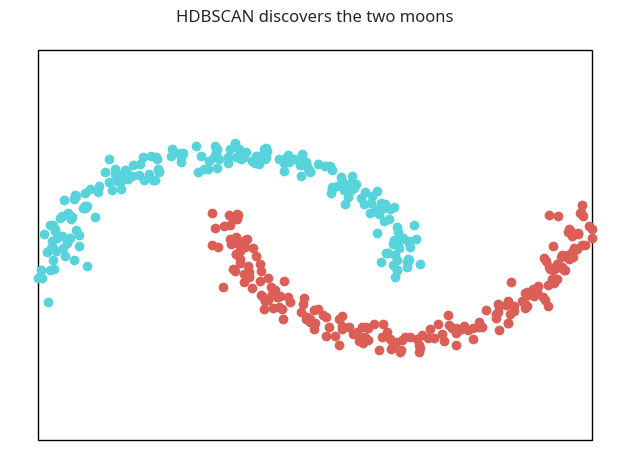

In [2]:
moons, _ = make_moons(n_samples=400, noise=0.06, random_state=42)
fig = hyp.plot(moons, 'o', ndims=2, cluster='HDBSCAN',
               title='HDBSCAN discovers the two moons')

## Soft clustering with Gaussian mixture models

Hard clustering assigns every point to exactly one cluster.  But real data is
often ambiguous!  When you pass `cluster='GaussianMixture'`, HyperTools colors
each observation by its proportional *blend* of cluster memberships.  On
overlapping blobs, points between clusters take on intermediate colors:

`n_clusters` is HyperTools' uniform name for the cluster count across every clustering model. Mixture models call it `n_components`, so HyperTools forwards it under that name: `n_clusters=3` here asks for three Gaussian components.

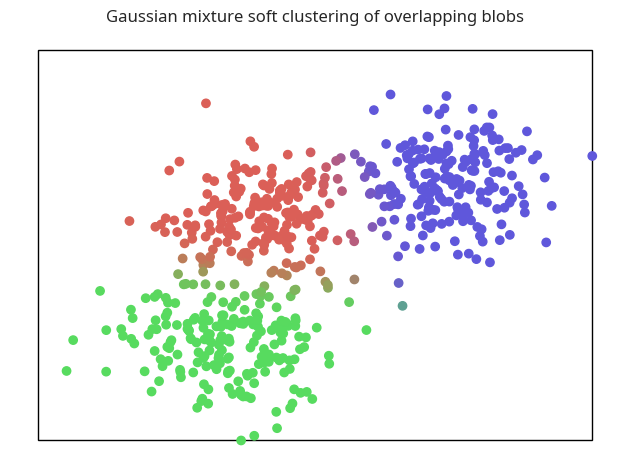

In [3]:
blobs, _ = make_blobs(n_samples=600, centers=3, cluster_std=2.5,
                      random_state=17)
fig = hyp.plot(blobs, 'o', ndims=2, cluster='GaussianMixture', n_clusters=3,
               title='Gaussian mixture soft clustering of overlapping blobs')

## Visualizing dynamics: the Lorenz attractor

HyperTools is also great for visualizing how systems evolve over time.  Here
we'll integrate the classic [Lorenz
system](https://en.wikipedia.org/wiki/Lorenz_system) with scipy:

In [4]:
def lorenz(t, state, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
    x, y, z = state
    return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

t = np.linspace(0, 50, 5000)
sol = solve_ivp(lorenz, (t[0], t[-1]), [1.0, 1.0, 1.0], t_eval=t)
trajectory = sol.y.T  # 5000 timepoints x 3 dimensions
trajectory.shape

(5000, 3)

Suppose we could only observe a *single* coordinate of the system.  Takens'
embedding theorem says we can still recover the attractor's geometry by
building a **time-delay embedding**: stacking time-lagged copies of the
observed coordinate into a matrix -- exactly what
`hyp.manip(x, model='Delay', tau=, dims=)` builds.  HyperTools takes care of
projecting that high-dimensional delay matrix back down to 3D.

Passing a continuous array as `hue` draws the trajectory as a multicolored
line, so color traces the passage of time:

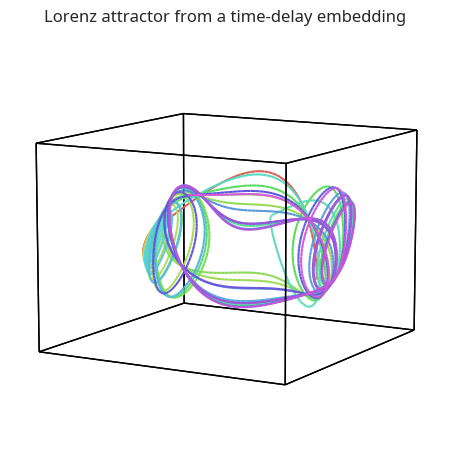

In [5]:
x = trajectory[:, 0]  # observe only the x-coordinate
tau, dims = 5, 20     # delay length and embedding dimension
delay_matrix = hyp.manip(x.reshape(-1, 1), model='Delay', tau=tau, dims=dims)
n = len(delay_matrix)

fig = hyp.plot(delay_matrix, hue=np.arange(n, dtype=float),
               title='Lorenz attractor from a time-delay embedding')

The butterfly-shaped attractor emerges from just one observed coordinate!

## Animating a trajectory

Finally, let's animate the trajectory itself.  With `animate=True`, HyperTools
sweeps a moving window along the timeseries -- slowly, over 20 seconds at 15
frames per second.  `save_path='modern_sklearn_dynamics.mp4'` encodes the
video directly (`.mp4` uses FFmpeg; a `.gif` needs no external tool at all):

In [6]:
anim = hyp.plot(trajectory, animate=True, duration=20, frame_rate=15,
                save_path='modern_sklearn_dynamics.mp4', show=False)

<video controls loop muted autoplay playsinline src="modern_sklearn_dynamics.mp4" title="The Lorenz attractor, drawn in over time" style="max-width: 100%"></video>

[Download the clip](modern_sklearn_dynamics.mp4)

## Next steps

Try `animate='spin'` for a rotating view, `chemtrails=True` to add a fading
tail to animated trajectories, or cluster the delay matrix itself with
`cluster='HDBSCAN'` to segment the attractor's lobes.